In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
import os

print(os.getcwd())

In [2]:
#load datasets
index_df = pd.read_csv('bus_need_index_final_full.csv')
demo_df  = pd.read_csv('nta_demographics_clean.csv')

print('Index columns:', index_df.columns.tolist())
print('Demo columns:', demo_df.columns.tolist()[:10], '...')
print(f'\nIndex rows: {len(index_df)}')
print(f'Demo rows:  {len(demo_df)}')

Index columns: ['NTACode', 'income_score', 'car_score', 'bus_subway_score', 'reliability_score', 'ridership_score', 'index_score']
Demo columns: ['NTA Code', 'Neighborhood Name', 'Borough', 'Population 16 years and over', 'In labor force', 'Civilian labor force', 'Employed', 'Unemployed', 'Armed Forces', 'Not in labor force'] ...

Index rows: 262
Demo rows:  262


In [3]:
print(demo_df.columns.tolist())

['NTA Code', 'Neighborhood Name', 'Borough', 'Population 16 years and over', 'In labor force', 'Civilian labor force', 'Employed', 'Unemployed', 'Armed Forces', 'Not in labor force', 'Civilian labor force (alt)', 'Unemployed (alt)', 'Own children under 6 years', 'All parents in family in labor force (children under 6)', 'Own children 6 to 17 years', 'All parents in family in labor force (children 6–17)', 'Total households', 'Household income less than $10,000', 'Household income $10,000 to $14,999', 'Household income $15,000 to $24,999', 'Household income $25,000 to $34,999', 'Household income $35,000 to $49,999', 'Household income $50,000 to $74,999', 'Household income $75,000 to $99,999', 'Household income $100,000 to $149,999', 'Household income $150,000 to $199,999', 'Household income $200,000 or more', 'Median household income', 'Mean household income', 'Households with Social Security', 'Households with retirement income', 'Households with Supplemental Security Income', 'Househol

In [4]:
demo_df = demo_df.rename(columns={'NTA Code': 'NTACode'})

combined = index_df[['NTACode', 'index_score']].merge(demo_df, on='NTACode', how='inner')
combined = combined.dropna(subset=['index_score'])

combined['snap_rate'] = (combined['Households with SNAP benefits'] / combined['Total households'])

print(f'NTAs in combined dataset: {len(combined)}')
combined[['NTACode', 'index_score', 'poverty_rate', 'snap_rate', 'Median household income']].head(5)

NTAs in combined dataset: 262


,NTACode,index_score,poverty_rate,snap_rate,Median household income
0,BK0101,0.608901,0.102933,0.074869,124903.0
1,BK0102,0.656246,0.154691,0.141550,145388.0
2,BK0103,0.789275,0.762459,0.473516,43465.0
3,BK0104,0.751316,0.272878,0.222809,79033.0
4,BK0201,0.609774,0.044206,0.031723,186162.0


In [5]:
# poverty rate vs. bus need score
df1 = combined.dropna(subset=['poverty_rate', 'index_score'])
r, p = stats.pearsonr(df1['poverty_rate'], df1['index_score'])
print(f'Pearson r: {r:.3f}')
print(f'p-value: {p:.10f}')
print(f'NTAs: {len(df1)}')
print(f'Significant: {"Yes" if p < 0.05 else "No"} (p < 0.05)')

Pearson r: 0.360
p-value: 0.0000000571
NTAs: 215
Significant: Yes (p < 0.05)


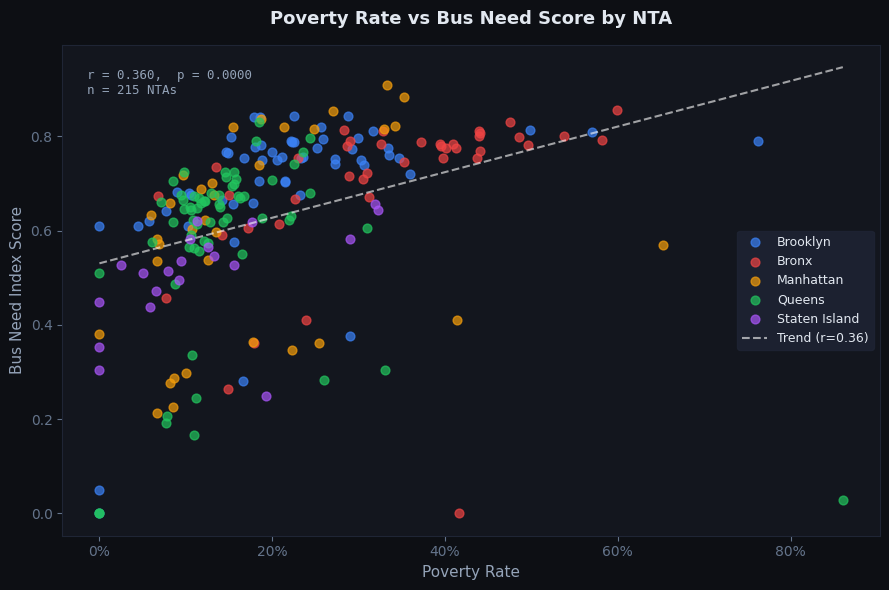

Saved: insight_poverty_vs_need.png


In [6]:
borough_colors = {'BK': '#3b82f6', 'BX': '#ef4444', 'MN': '#f59e0b',
                  'QN': '#22c55e', 'SI': '#a855f7'}
borough_names  = {'BK': 'Brooklyn', 'BX': 'Bronx', 'MN': 'Manhattan',
                  'QN': 'Queens',   'SI': 'Staten Island'}

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#0d0f14')
ax.set_facecolor('#13161e')

for prefix, color in borough_colors.items():
    mask = df1['NTACode'].str.startswith(prefix)
    ax.scatter(df1.loc[mask, 'poverty_rate'], df1.loc[mask, 'index_score'],
               c=color, alpha=0.7, s=40, label=borough_names[prefix])

m, b_val = np.polyfit(df1['poverty_rate'], df1['index_score'], 1)
x_range = np.linspace(df1['poverty_rate'].min(), df1['poverty_rate'].max(), 100)
ax.plot(x_range, m * x_range + b_val, color='white', linewidth=1.5,
        linestyle='--', alpha=0.6, label=f'Trend (r={r:.2f})')

ax.set_xlabel('Poverty Rate', color='#94a3b8', fontsize=11)
ax.set_ylabel('Bus Need Index Score', color='#94a3b8', fontsize=11)
ax.set_title('Poverty Rate vs Bus Need Score by NTA',
             color='#e2e8f0', fontsize=13, fontweight='bold', pad=15)
ax.tick_params(colors='#64748b')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
for spine in ax.spines.values():
    spine.set_edgecolor('#1f2535')
ax.legend(facecolor='#1f2535', labelcolor='#e2e8f0', edgecolor='#1f2535', fontsize=9)
ax.annotate(f'r = {r:.3f},  p = {p:.4f}\nn = {len(df1)} NTAs',
            xy=(0.03, 0.95), xycoords='axes fraction',
            color='#94a3b8', fontsize=9, va='top', fontfamily='monospace')

plt.tight_layout()
plt.savefig('insight_poverty_vs_need.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0f14')
plt.show()
print('Saved: insight_poverty_vs_need.png')

In [7]:
df2 = combined.dropna(subset=['snap_rate', 'index_score'])
r2, p2 = stats.pearsonr(df2['snap_rate'], df2['index_score'])
print(f'Pearson r: {r2:.3f}')
print(f'p-value: {p2:.10f}')
print(f'NTAs: {len(df2)}')

Pearson r: 0.460
p-value: 0.0000000000
NTAs: 210


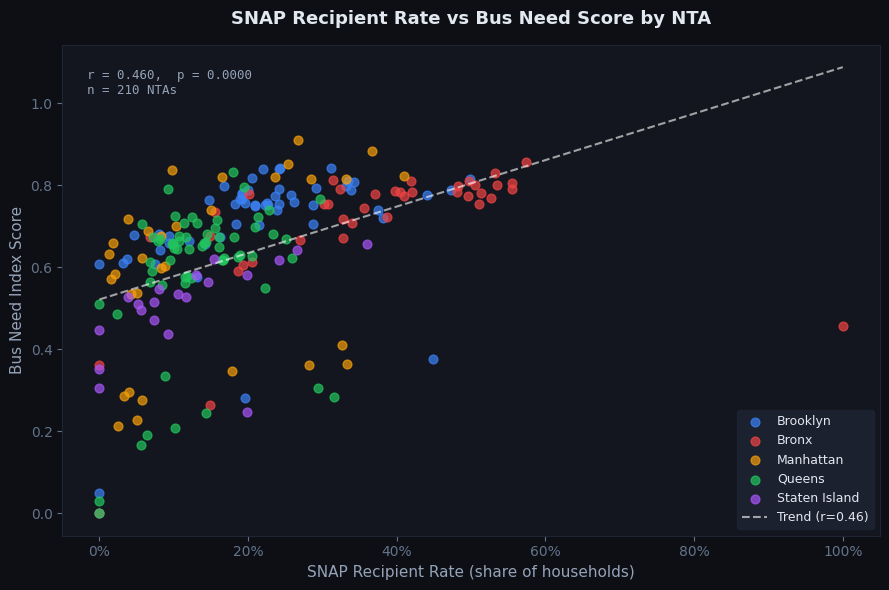

Saved: insight_snap_vs_need.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#0d0f14')
ax.set_facecolor('#13161e')

for prefix, color in borough_colors.items():
    mask = df2['NTACode'].str.startswith(prefix)
    ax.scatter(df2.loc[mask, 'snap_rate'], df2.loc[mask, 'index_score'],
               c=color, alpha=0.7, s=40, label=borough_names[prefix])

m2, b2 = np.polyfit(df2['snap_rate'], df2['index_score'], 1)
x2 = np.linspace(df2['snap_rate'].min(), df2['snap_rate'].max(), 100)
ax.plot(x2, m2 * x2 + b2, color='white', linewidth=1.5,
        linestyle='--', alpha=0.6, label=f'Trend (r={r2:.2f})')

ax.set_xlabel('SNAP Recipient Rate (share of households)', color='#94a3b8', fontsize=11)
ax.set_ylabel('Bus Need Index Score', color='#94a3b8', fontsize=11)
ax.set_title('SNAP Recipient Rate vs Bus Need Score by NTA',
             color='#e2e8f0', fontsize=13, fontweight='bold', pad=15)
ax.tick_params(colors='#64748b')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
for spine in ax.spines.values():
    spine.set_edgecolor('#1f2535')
ax.legend(facecolor='#1f2535', labelcolor='#e2e8f0', edgecolor='#1f2535', fontsize=9)
ax.annotate(f'r = {r2:.3f},  p = {p2:.4f}\nn = {len(df2)} NTAs',
            xy=(0.03, 0.95), xycoords='axes fraction',
            color='#94a3b8', fontsize=9, va='top', fontfamily='monospace')

plt.tight_layout()
plt.savefig('insight_snap_vs_need.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0f14')
plt.show()
print('Saved: insight_snap_vs_need.png')

In [9]:
variables = {
    'Poverty rate':             'poverty_rate',
    'SNAP recipient rate':      'snap_rate',
    'Median household income':  'Median household income',
    'Population below poverty': 'Population below poverty',
    'Unemployed':               'Unemployed',
}

results = []
for label, col in variables.items():
    if col not in combined.columns:
        print(f'WARNING: column "{col}" not found, skipping')
        continue
    df_tmp = combined.dropna(subset=[col, 'index_score'])
    r_val, p_val = stats.pearsonr(df_tmp[col], df_tmp['index_score'])
    results.append({
        'Variable':    label,
        'Pearson r':   round(r_val, 3),
        'p-value':     round(p_val, 4),
        'Significant': 'Yes' if p_val < 0.05 else 'No',
        'n':           len(df_tmp)
    })

results_df = pd.DataFrame(results).sort_values('Pearson r', ascending=False)
print(results_df.to_string(index=False))

                Variable  Pearson r  p-value Significant   n
Population below poverty      0.591      0.0         Yes 262
              Unemployed      0.587      0.0         Yes 262
     SNAP recipient rate      0.460      0.0         Yes 210
            Poverty rate      0.360      0.0         Yes 215
 Median household income     -0.467      0.0         Yes 210


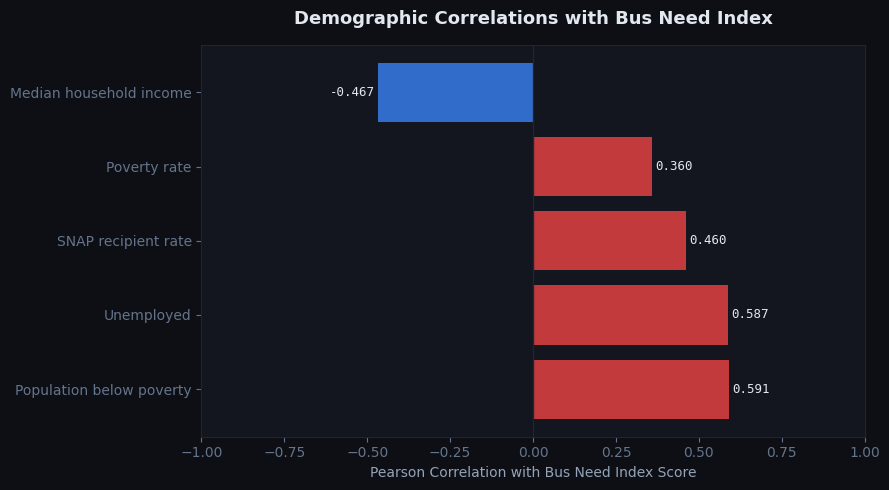

Saved: insight_correlations_summary.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0d0f14')
ax.set_facecolor('#13161e')

colors_bar = ['#ef4444' if r > 0 else '#3b82f6' for r in results_df['Pearson r']]
bars = ax.barh(results_df['Variable'], results_df['Pearson r'],
               color=colors_bar, alpha=0.8, edgecolor='none')

for bar, val in zip(bars, results_df['Pearson r']):
    x_pos = val + 0.01 if val >= 0 else val - 0.01
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha,
            color='#e2e8f0', fontsize=9, fontfamily='monospace')

ax.axvline(0, color='#1f2535', linewidth=1)
ax.set_xlabel('Pearson Correlation with Bus Need Index Score',
              color='#94a3b8', fontsize=10)
ax.set_title('Demographic Correlations with Bus Need Index',
             color='#e2e8f0', fontsize=13, fontweight='bold', pad=15)
ax.tick_params(colors='#64748b')
ax.set_xlim(-1, 1)
for spine in ax.spines.values():
    spine.set_edgecolor('#1f2535')

plt.tight_layout()
plt.savefig('insight_correlations_summary.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0f14')
plt.show()
print('Saved: insight_correlations_summary.png')

In [11]:
# demographics of people who live in high-need and low-need NTAs
combined_sorted = combined.sort_values('index_score', ascending=False)
top20    = combined_sorted.head(20)
bottom20 = combined_sorted.tail(20)

metrics = {
    'Poverty rate':           'poverty_rate',
    'SNAP rate':              'snap_rate',
    'Median income ($)':      'Median household income',
}

print(f'{"Metric":<30} {"Top 20 (High Need)":>20} {"Bottom 20 (Low Need)":>22}')
print('-' * 74)
for label, col in metrics.items():
    if col not in combined.columns:
        continue
    top_val    = top20[col].dropna().mean()
    bottom_val = bottom20[col].dropna().mean()
    if 'income' in col.lower():
        print(f'{label:<30} ${top_val:>18,.0f} ${bottom_val:>20,.0f}')
    else:
        print(f'{label:<30} {top_val:>19.1%} {bottom_val:>21.1%}')

print(f'\nTop 20 NTAs:')
for code, name in zip(top20['NTACode'], top20.get('Neighborhood Name', top20['NTACode'])):
    score = top20.loc[top20['NTACode']==code, 'index_score'].values[0]
    print(f'  {code}  {name}  ({score:.3f})')

Metric                           Top 20 (High Need)   Bottom 20 (Low Need)
--------------------------------------------------------------------------
Poverty rate                                 29.6%                 13.9%
SNAP rate                                    30.3%                  0.0%
Median income ($)              $            57,796 $             122,750

Top 20 NTAs:
  MN1101  East Harlem (South)  (0.910)
  MN0902  Manhattanville-West Harlem  (0.884)
  BX0601  West Farms  (0.857)
  MN0903  Hamilton Heights-Sugar Hill  (0.853)
  BK1101  Bensonhurst  (0.843)
  BK1303  Brighton Beach  (0.843)
  BK1401  Flatbush  (0.840)
  BK1701  East Flatbush-Erasmus  (0.840)
  MN0901  Morningside Heights  (0.837)
  QN0705  East Flushing  (0.831)
  BX0603  Belmont  (0.831)
  MN0301  Chinatown-Two Bridges  (0.823)
  MN1202  Washington Heights (North)  (0.820)
  MN1001  Harlem (South)  (0.819)
  BK1204  Mapleton-Midwood (West)  (0.819)
  MN1002  Harlem (North)  (0.815)
  MN1201  Washington Hei